### This file test the RePercENT model on synthetic data

In [48]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define imports here

In [49]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.models.perceiver import Perceiver
from src.models.repercent import DisenEncoder, RePercENT, DisenLoss
import math
from tqdm.notebook import tqdm

In [50]:
# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [51]:
N_data = 100000
latent_dim = {'Zs': 32, 'Z1': 32, 'Z2': 32}
mod_type= "rbf"
t1, t2 = 5, 5
gamma1, gamma2 = 2.0, 1.0
normalize = True
gen_data = GenerateData(N_data= N_data, mod_type= mod_type, latent_dims= latent_dim)
# gen_data.set_seed(0, device= device)
gen_data.create_dataset(t1= t1, t2= t2, gamma1= gamma1, gamma2= gamma2, normalize= normalize)
gen_data.print_dataset_info()

Modulation matrices not found, creating with default parameters for each modality.
before normalization sample: [[ 0.00878036  0.03475863 -0.01642928 -0.01852601 -0.03870521]
 [ 0.00593684  0.02387807 -0.01146697 -0.01313728 -0.02788603]
 [ 0.00373714  0.01527132 -0.00745109 -0.00867302 -0.01870445]
 [ 0.00218404  0.00906759 -0.00449499 -0.00531585 -0.01164771]
 [ 0.00118829  0.00501243 -0.00252452 -0.0030333  -0.0067527 ]]
after normalization sample: [[ 0.08363972  0.33110281 -0.1565016  -0.17647459 -0.36869708]
 [ 0.06390752  0.25703713 -0.123437   -0.14141722 -0.30018113]
 [ 0.04274306  0.17466387 -0.0852209  -0.09919656 -0.2139298 ]
 [ 0.02438988  0.10126063 -0.05019694 -0.05936375 -0.13007371]
 [ 0.01223141  0.05159424 -0.02598552 -0.0312226  -0.06950736]]
X1 shape: (100000, 5, 64), X2 shape: (100000, 5, 64)
Dataset Information:
Number of samples: 100000
Modality 1 data shape: 100000
Labels 1 shape: (100000,), Unique classes: [0 1]
Labels 2 shape: (100000,), Unique classes: [0 1]


In [52]:
dataset = MultimodalDataset(total_data= gen_data.dataset_dict['total_data'], labels_1 = gen_data.dataset_dict['labels_1'], labels_2=gen_data.dataset_dict['labels_2'], labels_s=gen_data.dataset_dict['labels_s'])

### Initialize the encoders for each modality:

$M_1$

In [53]:
# We want be using encoders for the synthetic data experiments, so we define identity encoders
enc_m1 = nn.Identity()

# Initialize the Perceiver module
DEPTH = 4
MAX_FREQ = math.ceil(t1 / 2) # set max freq to Nyquist frequency
NUM_FREQ_BANDS = 3
INPUT_CHANNELS= latent_dim['Z1'] + latent_dim['Zs'] # input channels = dim of unique component 1 + dim of shared component
INPUT_AXIS = 1 
LATENT_HEADS = 1
NUM_LATENTS = 2 # number of latent vectors, i.e. the number of disentangled factors to extract
LATENT_DIM = 32
CROSS_HEADS = 4
POS_ENCODING= True


per_m1 = Perceiver(num_freq_bands= NUM_FREQ_BANDS,
                    latent_dim= LATENT_DIM,
                    num_latents= NUM_LATENTS,
                  depth= DEPTH,
                  max_freq= MAX_FREQ,
                  latent_heads= LATENT_HEADS,
                  cross_heads= CROSS_HEADS,
                  input_channels= INPUT_CHANNELS,
                  input_axis= INPUT_AXIS,
                  fourier_encode_data= POS_ENCODING).to(device)

dissen_m1 = DisenEncoder(encoder_model= enc_m1, perceiver_model= per_m1).to(device)
dissen_m1.__repr__()

DisenEncoder with encoder: Identity() and perceiver: Perceiver(
  (layers): ModuleList(
    (0-3): 4 x ModuleList(
      (0): PreNorm(
        (fn): Attention(
          (to_q): Linear(in_features=32, out_features=256, bias=False)
          (to_kv): Linear(in_features=71, out_features=512, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_out): Linear(in_features=256, out_features=32, bias=True)
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm_context): LayerNorm((71,), eps=1e-05, elementwise_affine=True)
      )
      (1): PreNorm(
        (fn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=256, bias=True)
            (1): GEGLU()
            (2): Linear(in_features=128, out_features=32, bias=True)
            (3): Dropout(p=0.0, inplace=False)
          )
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (2): ModuleList(
  

$M_2$

In [54]:
# We want be using encoders for the synthetic data experiments, so we define identity encoders
enc_m2 = nn.Identity()

# Initialize the Perceiver module
DEPTH = 4
MAX_FREQ = math.ceil(t2 / 2) # set max freq to Nyquist frequency
NUM_FREQ_BANDS = math.floor(math.log2(MAX_FREQ)) + 1
INPUT_CHANNELS= latent_dim['Z2'] + latent_dim['Zs'] # input channels = dim of unique component 2 + dim of shared component
INPUT_AXIS = 1 # input axis = time points of modality 2
LATENT_HEADS = 1
NUM_LATENTS = 2 # number of latent vectors, i.e. the number of disentangled factors to extract
LATENT_DIM = 32
CROSS_HEADS = 4
POS_ENCODING= True


per_m2 = Perceiver(num_freq_bands= NUM_FREQ_BANDS,
                  latent_dim= LATENT_DIM,
                  num_latents= NUM_LATENTS,
                  depth= DEPTH,
                  max_freq= MAX_FREQ,
                  latent_heads= LATENT_HEADS,
                  cross_heads= CROSS_HEADS,
                  input_channels= INPUT_CHANNELS,
                  input_axis= INPUT_AXIS,
                  fourier_encode_data= POS_ENCODING).to(device)

dissen_m2 = DisenEncoder(encoder_model= enc_m2, perceiver_model= per_m2).to(device)
dissen_m2.__repr__()


DisenEncoder with encoder: Identity() and perceiver: Perceiver(
  (layers): ModuleList(
    (0-3): 4 x ModuleList(
      (0): PreNorm(
        (fn): Attention(
          (to_q): Linear(in_features=32, out_features=256, bias=False)
          (to_kv): Linear(in_features=69, out_features=512, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_out): Linear(in_features=256, out_features=32, bias=True)
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm_context): LayerNorm((69,), eps=1e-05, elementwise_affine=True)
      )
      (1): PreNorm(
        (fn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=256, bias=True)
            (1): GEGLU()
            (2): Linear(in_features=128, out_features=32, bias=True)
            (3): Dropout(p=0.0, inplace=False)
          )
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (2): ModuleList(
  

### Define the complete module

In [55]:
model = RePercENT(M= 2, disenEncoder= [dissen_m1, dissen_m2]).to(device)

### Tesing fwd pass and Augmentations in data

In [56]:
dataloader = DataLoader(dataset, batch_size= 16, shuffle= True)

for batch_idx, (data_m1, data_m2, labels_1, labels_2, labels_s) in enumerate(dataloader):
    data_m1 = data_m1.to(device)
    data_m2 = data_m2.to(device)
    print("Testing augmentation")

    data_m1_aug = gen_data.augment_data(data_m1, aug_type= "noise", snr= 20)
    data_m1_random_drop = gen_data.augment_data(data_m1, aug_type= "random_drop", drop_scale= 10)
    data_1_swap = gen_data.augment_data(data_m1, aug_type= "swap")
    print("Original Data Modality 1:", data_m1[0, 0, :])
    print("Augmented Data Modality 1 (Noise):", data_m1_aug[0, 0, :])
    print("Augmented Data Modality 1 (Random Drop):", data_m1_random_drop[0, 0, :])
    print("Augmented Data Modality 1 (Swap):", data_1_swap[0, 0, :])
    # outputs = model(data_m1, data_m2)
    # print(f"Batch {batch_idx+1}:")
    # for i, (output, val) in enumerate(outputs.items()):
    #     print(f" Model output {i+1} - {output}: {val}")
    break  # Just process one batch for demonstration

Testing augmentation
Original Data Modality 1: tensor([-0.0151,  0.1062,  0.0624,  0.3450, -0.0871,  0.2345,  0.0166, -0.1314,
         0.1563,  0.0401, -0.0458,  0.0726,  0.1173, -0.0007, -0.2752, -0.1504,
         0.0299,  0.1813,  0.2066, -0.0132, -0.2164, -0.1147, -0.1285,  0.0450,
        -0.2049,  0.2053, -0.2128,  0.2938, -0.2230, -0.0659, -0.0729,  0.0475,
        -0.1147, -0.0352, -0.0931, -0.0624, -0.0864, -0.1295,  0.0392,  0.1456,
         0.0244,  0.0923, -0.2175, -0.1778,  0.1072,  0.0649,  0.0110,  0.0569,
        -0.0789, -0.0011,  0.0703, -0.0670, -0.0404, -0.0092, -0.0518, -0.0436,
        -0.0033, -0.0185, -0.0048, -0.0624,  0.0027, -0.0128,  0.0016,  0.0048],
       device='cuda:0')
Augmented Data Modality 1 (Noise): tensor([-0.0108,  0.1169,  0.0711,  0.3326, -0.0971,  0.2513,  0.0180, -0.1218,
         0.1564,  0.0348, -0.0356,  0.0700,  0.1265,  0.0042, -0.2787, -0.1440,
         0.0583,  0.1833,  0.2108, -0.0068, -0.2183, -0.1069, -0.1108,  0.0499,
        -0.18

### Define training loop

In [60]:
# Training loop with logistic regression probing for disentanglement evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Training hyperparameters
alpha = 0.5
lmd = 0.001
dissen_loss = DisenLoss(alpha=alpha, lmd=lmd)
EPOCHS = 50
BATCH_SZ = 4048
LR = 0.01
dataloader = DataLoader(dataset, batch_size=BATCH_SZ, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Training logs
train_loss_logs = {
    "loss": [], "loss_ortho": [], "loss_unique": [], "loss_shared": [],
    "acc_u12_l1": [], "acc_s21_ls": [], "acc_u21_l2": [], "acc_s12_ls": []
}

print(f"Training with device: {device}\n")

# Training loop
for _iter in range(EPOCHS):
    epoch_loss = 0.0
    epoch_ortho_loss = 0.0
    epoch_unique_loss = 0.0
    epoch_shared_loss = 0.0
    
    model.train()
    
    print(f"----- Epoch: {_iter + 1} / {EPOCHS} -----")
    
    # Training phase
    for batch_idx, (data_m1, data_m2, _, _, _) in enumerate(dataloader):
        temp_b = data_m1.shape[0]
        # print(f"  Batch: {batch_idx + 1} / {len(dataloader)}", end='\r')
        data_m1 = data_m1.to(device)
        data_m2 = data_m2.to(device)
        
        # Augment data 
        data_m1_aug = gen_data.augment_data(data_m1, aug_type="random")
        data_m2_aug = gen_data.augment_data(data_m2, aug_type="random")
        
        # Forward pass through RePercENT
        outputs = model(data_m1, data_m2)
        outputs_aug = model(data_m1_aug, data_m2_aug)
        
        # Compute disentanglement loss
        loss_train, logs_train = dissen_loss(outputs, outputs_aug)
        
        # Backward pass for RePercENT
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        # Track losses
        epoch_loss += loss_train.item()/ temp_b
        epoch_ortho_loss += logs_train["ortho"]/ temp_b
        epoch_unique_loss += logs_train["unique"]/ temp_b
        epoch_shared_loss += logs_train["shared"]/ temp_b
    
    # Epoch statistics
    avg_epoch_loss = epoch_loss / len(dataloader)
    avg_ortho_loss = epoch_ortho_loss / len(dataloader)
    avg_unique_loss = epoch_unique_loss / len(dataloader)
    avg_shared_loss = epoch_shared_loss / len(dataloader)
    
    # Log results
    train_loss_logs["loss"].append(avg_epoch_loss)
    train_loss_logs["loss_ortho"].append(avg_ortho_loss)
    train_loss_logs["loss_unique"].append(avg_unique_loss)
    train_loss_logs["loss_shared"].append(avg_shared_loss)
    

    print(f"  Loss(x 100): {avg_epoch_loss* 100:.5f} | Ortho (x 100): {avg_ortho_loss* 100:.5f} | Unique (x 100): {avg_unique_loss* 100:.5f} | Shared (x 100): {avg_shared_loss* 100:.5f}")
    # print(f"  Acc u_12→l1: {acc_u12_l1:.1f}% | s_21→ls: {acc_s21_ls:.1f}% | u_21→l2: {acc_u21_l2:.1f}% | s_12→ls: {acc_s12_ls:.1f}%\n")

print("Training complete!")

Training with device: cuda

----- Epoch: 1 / 50 -----
  Loss(x 100): 0.28183 | Ortho (x 100): 199.99906 | Unique (x 100): 0.20815 | Shared (x 100): 0.28183
----- Epoch: 2 / 50 -----
  Loss(x 100): 0.28177 | Ortho (x 100): 199.99898 | Unique (x 100): 0.20815 | Shared (x 100): 0.28177
----- Epoch: 3 / 50 -----
  Loss(x 100): 0.28191 | Ortho (x 100): 199.99892 | Unique (x 100): 0.20815 | Shared (x 100): 0.28191
----- Epoch: 4 / 50 -----
  Loss(x 100): 0.28181 | Ortho (x 100): 199.99830 | Unique (x 100): 0.20815 | Shared (x 100): 0.28181
----- Epoch: 5 / 50 -----
  Loss(x 100): 0.28196 | Ortho (x 100): 199.99389 | Unique (x 100): 0.20814 | Shared (x 100): 0.28196
----- Epoch: 6 / 50 -----
  Loss(x 100): 0.28181 | Ortho (x 100): 199.99110 | Unique (x 100): 0.20814 | Shared (x 100): 0.28181
----- Epoch: 7 / 50 -----
  Loss(x 100): 0.28174 | Ortho (x 100): 199.91311 | Unique (x 100): 0.20814 | Shared (x 100): 0.28174
----- Epoch: 8 / 50 -----
  Loss(x 100): 0.28167 | Ortho (x 100): 199.90135 

KeyboardInterrupt: 

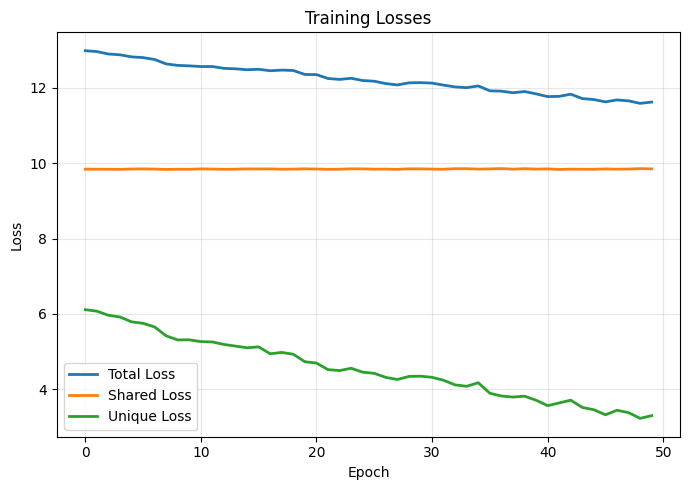

In [ ]:
import matplotlib.pyplot as plt

# Plot training losses and accuracies
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Loss components
axes.plot(train_loss_logs["loss"], label="Total Loss", linewidth=2)
axes.plot(train_loss_logs["loss_shared"], label="Shared Loss", linewidth=2)
axes.plot(train_loss_logs["loss_unique"], label="Unique Loss", linewidth=2)
# axes.plot(train_loss_logs["loss_ortho"], label="Ortho Loss", linewidth=2)

axes.set_xlabel("Epoch")
axes.set_ylabel("Loss")
axes.set_title("Training Losses")
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
